# System identification by differentiating an extended Kalman filter

Given a record of noisy position measurements of a nonlinear oscillator, find its physical
parameters and noise levels by **maximum likelihood**. The likelihood of a state-space model is
computed by a Kalman filter, so fitting it means differentiating *through the filter* — through
every prediction, every Jacobian linearization and every covariance update, over hundreds of steps.
Scaly does this with one reverse sweep.

| Scaly feature | Where |
| --- | --- |
| `sc.scan` with sliced (stride 1) and broadcast (stride 0) inputs | the whole EKF as one loop |
| `sc.jacobian` inside the scan body | the EKF's linearization of an RK4 step |
| `sc.gradient` through the scan (reverse mode) | the gradient of the negative log-likelihood, including the derivative of those Jacobians |
| typed `Function` outputs | the filter's estimates and innovations for diagnostics |

The script version is `examples/ekf_identification.py`.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize

import plotstyle
import scaly as sc
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "ekf_identification"

## Model and data

A forced Duffing oscillator (a stiffening spring $k x_1 + k_3 x_1^3$ and a damper $c$) driven by a
known force $u(t)$ and an unknown random force $w$:

$$
\dot x_1 = x_2, \qquad \dot x_2 = -k x_1 - k_3 x_1^3 - c x_2 + u(t) + w, \qquad y_k = x_1(t_k) + v_k .
$$

The unknowns are $\theta = (\log c, \log k_3, \log q, \log r)$: damping, spring nonlinearity, and the
intensities of the process noise $w$ and the measurement noise $v$ (logs keep them positive). The
record has $T = 600$ samples at $\Delta t = 0.05$ s.

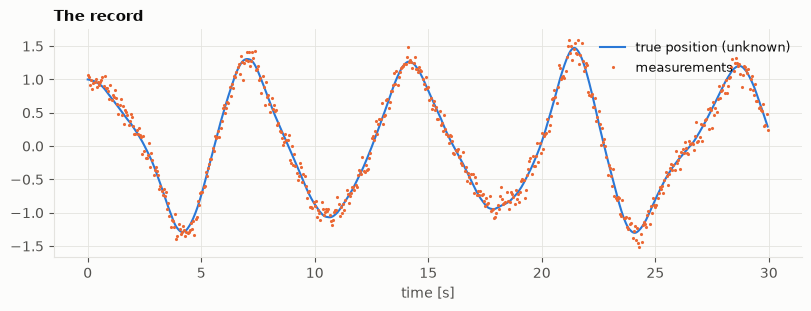

In [2]:
T, DT, K_LIN = 600, 0.05, 1.0
THETA_TRUE = np.log([0.3, 0.8, 0.02, 0.01])
NAMES = ["c", "k3", "q", "r"]


def simulate(theta, seed=0):
  c, k3, q, r = np.exp(theta)
  rng = np.random.default_rng(seed)
  u = 1.2 * np.cos(0.9 * DT * np.arange(T))
  cov = q * np.array([[DT**3 / 3, DT**2 / 2], [DT**2 / 2, DT]])  # white noise integrated over a step
  x, xs, y = np.array([1.0, 0.0]), np.zeros((T, 2)), np.zeros(T)

  def f(x, uk):
    return np.array([x[1], -K_LIN * x[0] - k3 * x[0] ** 3 - c * x[1] + uk])

  for k in range(T):
    k1 = f(x, u[k])
    k2 = f(x + 0.5 * DT * k1, u[k])
    k3_ = f(x + 0.5 * DT * k2, u[k])
    k4 = f(x + DT * k3_, u[k])
    x = x + DT / 6 * (k1 + 2 * k2 + 2 * k3_ + k4) + rng.multivariate_normal(np.zeros(2), cov)
    xs[k] = x
    y[k] = x[0] + np.sqrt(r) * rng.standard_normal()
  return y, u, xs


y, u, truth = simulate(THETA_TRUE)
t = DT * np.arange(T)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t, truth[:, 0], color=plotstyle.BLUE, lw=1.5, label="true position (unknown)")
ax.plot(t, y, ".", color=plotstyle.ORANGE, ms=2.5, label="measurements")
ax.set_xlabel("time [s]")
ax.set_title("The record")
ax.legend(loc="upper right", fontsize=9)
plt.show()

## The EKF as one scan

The carry is the belief $(\hat x, P)$. One step:

1. **predict** with an RK4 step $\hat x^- = F(\hat x)$ and its Jacobian $A = \partial F / \partial \hat x$
   (`sc.jacobian`), $P^- = A P A^\top + Q_d(q)$;
2. **update** with the innovation $e = y_k - \hat x_1^-$, its variance $S = P^-_{11} + r$ and gain
   $K = P^-_{:,1}/S$, using the Joseph form $P = (I - KH)P^-(I - KH)^\top + r K K^\top$;
3. add $\tfrac12(\log 2\pi S + e^2/S)$ to the negative log-likelihood.

Measurements and forcing are sliced one per step; $\theta$ is broadcast (stride 0) to every step.
Stacked outputs record the innovation, its variance and the filtered belief at every step, for the
diagnostics further down.

In [3]:
def rk4(x, u_k, c, k3):
  def f(x):
    return sc.stack([x[1], -K_LIN * x[0] - k3 * x[0] * x[0] * x[0] - c * x[1] + u_k])

  k1 = f(x)
  k2 = f(x + 0.5 * DT * k1)
  k3_ = f(x + 0.5 * DT * k2)
  k4 = f(x + DT * k3_)
  return x + DT / 6 * (k1 + 2 * k2 + 2 * k3_ + k4)


@sc.function(6, 2, 4, output=sc.G("belief_next", "nll", "innovation", "S", "belief_log"))
def ekf_step(belief, yu, theta):
  x, p = belief[:2], belief[2:].reshape((2, 2))
  y_k, u_k = yu[0], yu[1]
  c, k3, q, r = theta[0].exp(), theta[1].exp(), theta[2].exp(), theta[3].exp()
  x_pred = rk4(x, u_k, c, k3)
  a = sc.jacobian(x_pred, x)
  p_pred = a @ p @ a.T + sc.const(np.array([[DT**3 / 3, DT**2 / 2], [DT**2 / 2, DT]])) * q
  e = y_k - x_pred[0]
  s = p_pred[0, 0] + r
  gain = p_pred[:, 0] / s
  i_kh = sc.const(np.eye(2)) - sc.stack([gain, sc.const(np.zeros(2))], axis=1)
  p_next = i_kh @ p_pred @ i_kh.T + r * gain.reshape((2, 1)) @ gain.reshape((1, 2))
  nll = 0.5 * (s.log() + e * e / s + np.log(2 * np.pi))
  belief_next = sc.concat([x_pred + gain * e, p_next.reshape((4,))])
  return belief_next, nll.reshape((1,)), e.reshape((1,)), s.reshape((1,)), belief_next


@sc.function(4, T, T, output=sc.G("nll", "grad"))
def likelihood(theta, y, u):
  yu = sc.stack([y, u], axis=1).reshape((2 * T,))
  _, nlls, _, _, _ = sc.scan(ekf_step, sc.const(np.array([0.0, 0.0, 1.0, 0.0, 0.0, 1.0])), [(yu, 0, 2), (theta, 0, 0)], length=T)
  value = nlls.sum()
  return value, sc.gradient(value, theta)


@sc.function(4, T, T, output=sc.G("estimates", "innovations", "S"))
def run_filter(theta, y, u):
  yu = sc.stack([y, u], axis=1).reshape((2 * T,))
  _, _, innovations, s, beliefs = sc.scan(ekf_step, sc.const(np.array([0.0, 0.0, 1.0, 0.0, 0.0, 1.0])), [(yu, 0, 2), (theta, 0, 0)], length=T)
  return beliefs.reshape((T, 6)), innovations, s

## The gradient, checked

`sc.gradient(value, theta)` runs the scan forwards, storing each belief, and then backwards,
propagating the adjoint through the Joseph update, the gain, the covariance prediction and — since
$A$ depends on $\hat x$ and on $c, k_3$ — through the derivative of the RK4 Jacobian itself, i.e.
second derivatives of the dynamics. Writing that by hand is where adjoint Kalman-filter codes go
wrong; here it is checked against central differences.

In [4]:
theta0 = np.log([1.0, 0.1, 0.1, 0.1])
value, grad = likelihood(theta0, y, u)
eps = 1e-6
fd = np.array([(likelihood(theta0 + eps * e, y, u)[0] - likelihood(theta0 - eps * e, y, u)[0]) / (2 * eps) for e in np.eye(4)])
print("reverse mode:       ", grad)
print("central differences:", fd)
start = time.perf_counter()
for _ in range(100):
  likelihood(theta0, y, u)
print(f"NLL and gradient through {T} EKF steps: {1e3 * (time.perf_counter() - start) / 100:.2f} ms per call")

reverse mode:        [ 79.8031001  -14.04162373 -72.64639485 249.29935642]
central differences: [ 79.80310012 -14.04162375 -72.64639484 249.29935645]
NLL and gradient through 600 EKF steps: 0.20 ms per call


## Maximum likelihood with L-BFGS

In [5]:
path = [theta0]
fit = optimize.minimize(lambda th: likelihood(th, y, u), theta0, jac=True, method="L-BFGS-B", callback=lambda th: path.append(th.copy()))
path = np.array(path)
nll_path = np.array([likelihood(th, y, u)[0] for th in path])
print(f"{fit.nit} iterations, {fit.nfev} evaluations; NLL {nll_path[0]:.1f} -> {fit.fun:.1f} (at the true parameters: {likelihood(THETA_TRUE, y, u)[0]:.1f})")
for name, fitted, true in zip(NAMES, np.exp(fit.x), np.exp(THETA_TRUE), strict=True):
  print(f"  {name:>2}: fitted {fitted:.4f}, true {true:.4f}")

19 iterations, 24 evaluations; NLL 14.1 -> -468.9 (at the true parameters: -466.7)
   c: fitted 0.3253, true 0.3000
  k3: fitted 0.7948, true 0.8000
   q: fitted 0.0330, true 0.0200
   r: fitted 0.0103, true 0.0100


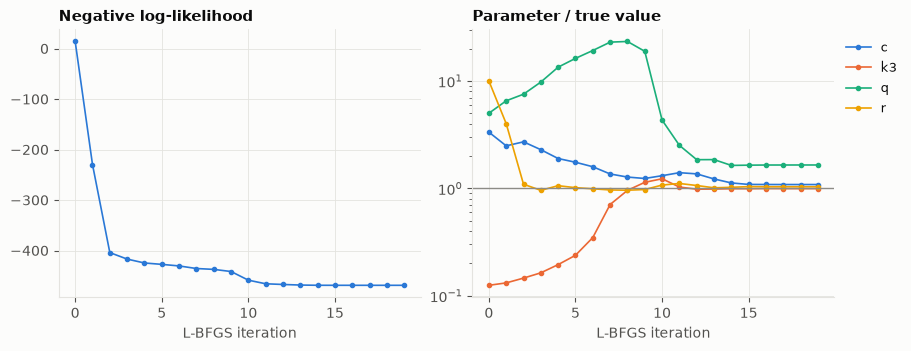

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4))
ax1.plot(nll_path, "o-", ms=3, lw=1.2, color=plotstyle.BLUE)
ax1.set_title("Negative log-likelihood")
ax1.set_xlabel("L-BFGS iteration")
for i, name in enumerate(NAMES):
  ratio = np.exp(path[:, i] - THETA_TRUE[i])
  ax2.semilogy(ratio, "o-", ms=3, lw=1.2, color=plotstyle.SERIES[i], label=name)
ax2.axhline(1, color=plotstyle.NEUTRAL, lw=1)
ax2.set_title("Parameter / true value")
ax2.set_xlabel("L-BFGS iteration")
ax2.legend(fontsize=9, loc="upper left", bbox_to_anchor=(1.0, 1.0))
for ax in (ax1, ax2):
  ax.xaxis.get_major_locator().set_params(integer=True)
plt.show()

The damping, the nonlinearity and the measurement noise are recovered to within a few percent; the
process-noise intensity $q$, which only the fine structure of the record informs, less precisely.
The NLL at the fit is below its value at the true parameters, as it must be for a maximum-likelihood
estimate on a finite record.

## The likelihood landscape

A slice of the NLL over $(c, k_3)$ with the noise levels fixed at their fitted values: 1600 runs of
the 600-step filter, a fraction of a second in total.

1600 likelihood evaluations with gradients in 0.14 s


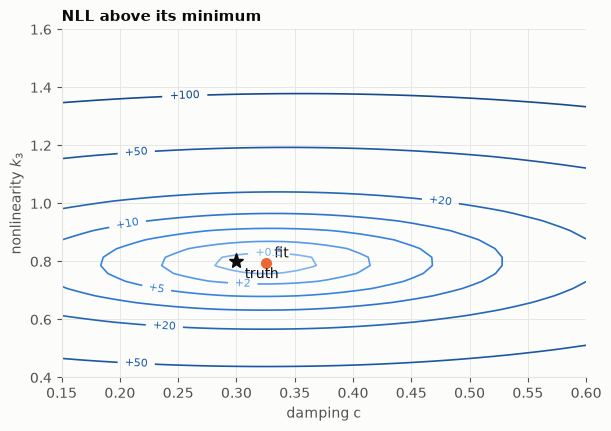

In [7]:
cs, k3s = np.linspace(np.log(0.15), np.log(0.6), 40), np.linspace(np.log(0.4), np.log(1.6), 40)
start = time.perf_counter()
grid = np.array([[likelihood(np.array([lc, lk, fit.x[2], fit.x[3]]), y, u)[0] for lc in cs] for lk in k3s])
print(f"{grid.size} likelihood evaluations with gradients in {time.perf_counter() - start:.2f} s")
fig, ax = plt.subplots(figsize=(6, 4.2))
levels = fit.fun + np.r_[0.5, 2, 5, 10, 20, 50, 100, 200]
shades = [plotstyle.BLUES(v) for v in np.linspace(0.35, 0.95, len(levels))]
cs_ = ax.contour(np.exp(cs), np.exp(k3s), grid, levels=levels, colors=shades, linewidths=1.2)
ax.clabel(cs_, fmt=lambda v: f"+{v - fit.fun:.0f}" if v - fit.fun >= 1 else f"+{v - fit.fun:.1f}", fontsize=8)
ax.plot(*np.exp(fit.x[:2]), "o", color=plotstyle.ORANGE, ms=7)
ax.annotate("fit", np.exp(fit.x[:2]), xytext=(6, 4), textcoords="offset points")
ax.plot(*np.exp(THETA_TRUE[:2]), "*", color=plotstyle.TEXT, ms=11)
ax.annotate("truth", np.exp(THETA_TRUE[:2]), xytext=(6, -12), textcoords="offset points")
ax.set_xlabel("damping c")
ax.set_ylabel(r"nonlinearity $k_3$")
ax.set_title("NLL above its minimum")
plt.show()

## Diagnostics: estimates and innovations

A well-specified filter has *white* normalized innovations $e_k/\sqrt{S_k}$ with unit variance, and
state estimates whose errors stay mostly within $\pm 2\sqrt{P}$. The initial guess fails both tests;
the fitted model passes them.

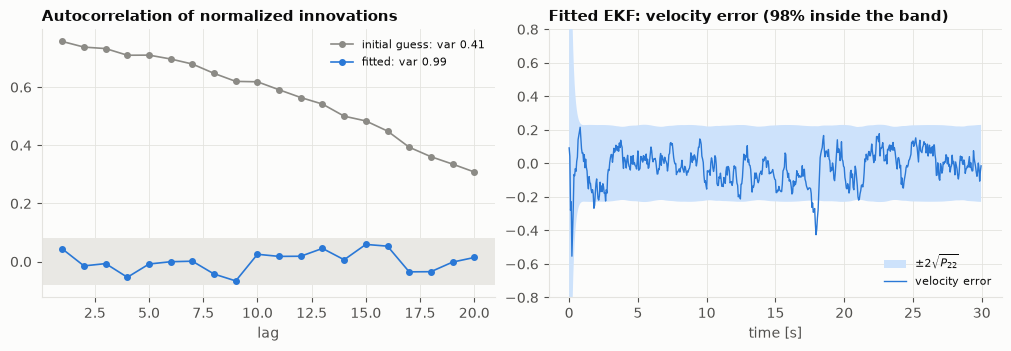

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for theta, label, colour in ((theta0, "initial guess", plotstyle.NEUTRAL), (fit.x, "fitted", plotstyle.BLUE)):
  estimates, innovations, s = run_filter(theta, y, u)
  z = innovations / np.sqrt(s)
  lags = np.arange(1, 21)
  acf = np.array([np.corrcoef(z[:-lag], z[lag:])[0, 1] for lag in lags])
  axes[0].plot(lags, acf, "o-", ms=4, lw=1.2, color=colour, label=f"{label}: var {z.var():.2f}")
  if theta is fit.x:
    err = estimates[:, 1] - truth[:, 1]
    band = 2 * np.sqrt(estimates[:, 5])
    axes[1].fill_between(t, -band, band, color="#cde2fb", lw=0, label=r"$\pm 2\sqrt{P_{22}}$")
    axes[1].plot(t, err, color=plotstyle.BLUE, lw=1, label="velocity error")
    inside = np.mean(np.abs(err) <= band)
bound = 2 / np.sqrt(T)
axes[0].axhspan(-bound, bound, color="#e9e8e4", lw=0)
axes[0].set_title("Autocorrelation of normalized innovations")
axes[0].set_xlabel("lag")
axes[0].legend(fontsize=8)
axes[1].set_title(f"Fitted EKF: velocity error ({100 * inside:.0f}% inside the band)")
axes[1].set_xlabel("time [s]")
axes[1].set_ylim(-0.8, 0.8)  # the first half second, from a unit initial covariance, is off the scale
axes[1].legend(fontsize=8, loc="lower right")
plt.show()

The shaded band on the left is the $\pm 2/\sqrt{T}$ region expected for white noise.

## Generated code

The likelihood-and-gradient function (forward scan, stored beliefs, backward scan) is one C function.

In [9]:
for fn in (likelihood, run_filter):
  module = write_module(fn, GENERATED)
  print(f"{module.source_name}: {len(module.source.splitlines())} lines, workspace {module.workspace_size} doubles")

likelihood.c: 354 lines, workspace 7206 doubles
run_filter.c: 170 lines, workspace 4800 doubles
